In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.ticker as mticker

import freealg
from freealg import AlgebraicForm
from freealg.distributions import DeformedMarchenkoPastur
from freealg.visualization import plot_flow, plot_mass, ridgeplot, plot_edges
from freealg.visualization._api_plot_util import _k_pow2_formatter

plot_dir = './plots'
title = 'Deformed Marchenko-Pastur'
latex = True

# Deformed MP

In [25]:
config1 = dict(
    input_filename = 'deformed_mp_eigs.npz',
    deg_m = 3,
    # effective_n = 80_000,
    xlim = (0.5, 8),
    ylim = [(0.0, 2.55), (0.0, 2.55), (0.0, 0.52)],
    nbins = (80, 120),
    label_mode = 'pow-int',
    save_filename = 'dmp',
)

# -------

config = config1

[(1.005518159668944, 3.1256892314391456), (4.16272377987857, 7.595354543299054)]


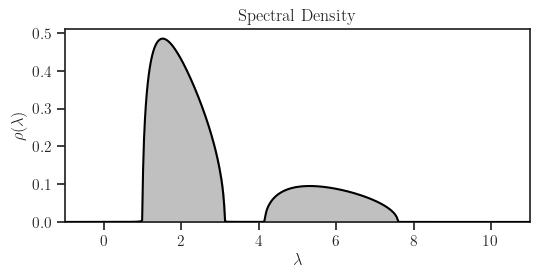

In [3]:
filename = 'deformed_mp'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dist = DeformedMarchenkoPastur(t=[t1, t2], w=[w1, 1-w1], c=lam)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=latex, save=False)

In [29]:
# # Create data if not exists
# A = dist.matrix(8000, seed=0)
# eig_A = numpy.linalg.eigvalsh(A)

# As = freealg.submatrix(A, 1000, seed=0)
# eig_As = numpy.linalg.eigvalsh(As)

# out = {
#     'eig_A': eig_A,
#     'eig_As': eig_As,
#     'lam': lam,
#     't': [t1, t2],
#     'w1': w1,
#     'n': A.shape[0],
#     'n0': As.shape[0]
# }

# filename = 'dmp.npz'
# dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
# out_filename = join(dir_, filename)
# numpy.savez(out_filename, out=numpy.array(out, dtype=object))

In [4]:
# # Load data if already created before
# filename = 'dmp.npz'
# dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
# out_filename = join(dir_, filename)

# data = numpy.load(out_filename, allow_pickle=True)
# out = data['out'].item()

# eig_A = out['eig_A']
# eig_As = out['eig_As']
# n = out['n']
# n0 = out['n0']

# Submatrices

Idx   Size
---  -----
0     1000
1     2000
2     4000
3     8000
4    16000
5    32000



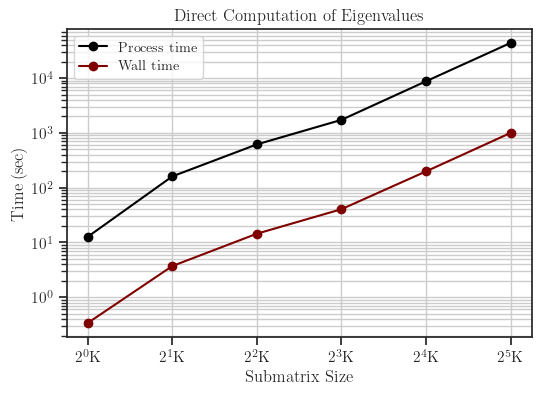

In [4]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

# Sizes of submatrices
print('Idx   Size')
print('---  -----')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}')
print('')
# print(f'proc name: {proc_name}')
# print(f'num proc:  {num_proc}')
# print(f'date:      {date}')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

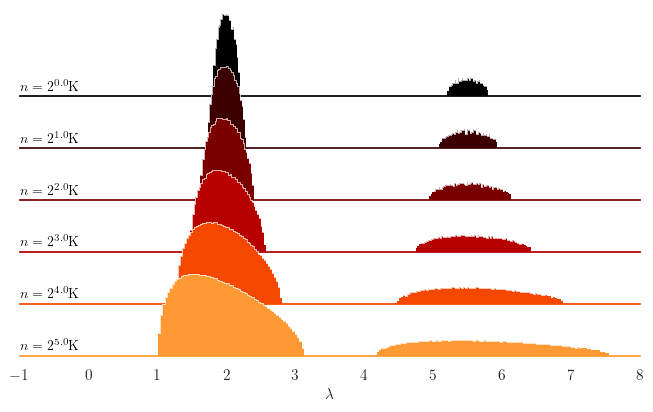

In [5]:
ridgeplot(sizes, eigs=eigs, log=False, scaley=True, hspace=-0.4,
          text_side='left', xlim=(-1, 8), ylim=None, figsize=(8, 4.5),
          # label_mode='pow-int',
          label_mode='pow-dec',
          latex=latex, title='',
          save=False, nbins=200)

# Fit Spectral Curve

In [6]:
# Index to choose the initial sub-matrix size
start_idx = 0

# Detect support from histogram
print('\n------------------------------------------')
print('Support (detected from histogram):')
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=False,
                      print_info=True)

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 20,
    anchor_mode = 'asymptote',   # empirical, asymptotic
    anchor_y_min = 1e-4,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 1,
    anchor_ratio = 0.01,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
    # anchor_match_tol = numpy.inf,  # disables anchor retry
    # anchor_ratio_tol = numpy.inf,
    anchor_match_tol = 0.1,       # retry if init anchor not mathc roots
    anchor_ratio_tol = 0.9,
    anchor_retry_factor = 3.0     # factor to multiple anchor height in retrial
)

# Inverse Stieltjes options
inv_stieltjes_opt = dict(
    delta = 1e-5,
    delta_ladder_ratio = 2.0,
    delta_ladder_size = 1,
    delta_ladder_grid = 'linear',   # geometric, linear
    z_query_delta = 'const',       # const, linear
    method = 'direct',             # direct, polyfit, chebfit, poisson
    fit_degree = 2,
    reg = 0.0,
    fit_weight = 'uniform',  # 'uniform, small_delta
)

# Estimate the initia ratio "c0" from "c" of the larger matrix
ratio = dist.ratio * (sizes[start_idx] / sizes[-1])

# Main object
# af = AlgebraicForm(eig_As,
af = AlgebraicForm(eigs[start_idx],
                   ratio=ratio,
                   support=None,
                   # support=support,
                   n=sizes[start_idx],
                   log=False,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt,
                   inv_stieltjes_opt=inv_stieltjes_opt)

# Polynomial degrees
deg_m = config['deg_m']
deg_z = 2

# Moments to be used as constraints in fitting
deg_mu = 0
mu = numpy.zeros((deg_mu+1, ), dtype=float)
mu[0] = 1.0
for i in range(1, mu.size):
    if i == 1:
        mu[i] = numpy.mean(af.eig)
    else:
        mu[i] = numpy.mean(af.eig**i)

print('\n------------------------------------------')
coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r_min=1.8, r_max=2.2, n_r=5,
    y_scale=1.0, gamma=1.0,
    n_samples=4096,
    cut_eps=0.01,
    normalize=True,
    # normalize=False,
    # triangular=(None, None),
    triangular=None,
    # triangular=(-1, 1),
    mu=mu,
    # mu=None,
    mu_reg=None, verbose=True, plot=False)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
| bulk 1 | interval: (  1.81095,   2.21473) | center:   2.01284 |  mass: 74.40% |
| bulk 2 | interval: (  5.17579,   5.82183) | center:   5.49881 |  mass: 25.60% |
mass(x) ~ 1.026 + -0.1400 * x

------------------------------------------
fit residual max  : 5.1510e-07
fit residual 99.9%: 5.1498e-07

Coefficients (real)
+0.82109293 -2.05725563 +0.24123154 +0.00266126 
-0.17890707 +1.35713417 -0.15284311 -0.00338251 
+0.00000000 -0.17890707 +0.01793698 +0.00076347 

Coefficients (imag) norm: 0.0000e+00


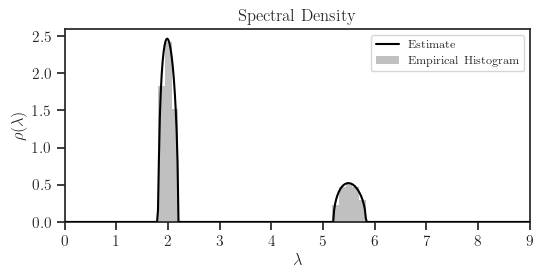

mass: 1.000755


In [7]:
# x_min, x_max = config['xlim']
x0 = numpy.linspace(x_min, x_max, 500)
rho0 = af.density(x0, plot=True, latex=latex)

mass = numpy.trapz(rho0, x0)
print('mass: %f' % mass)

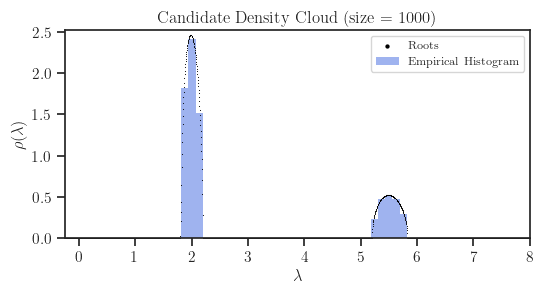

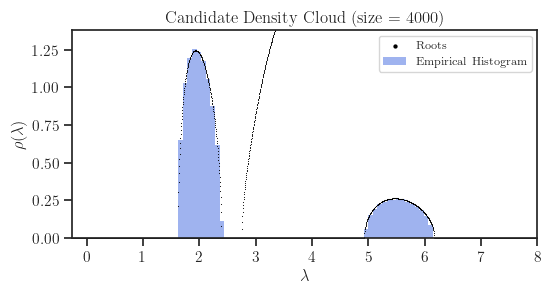

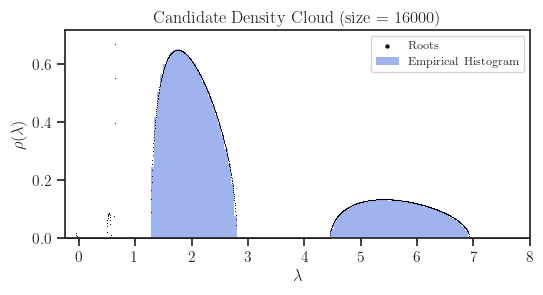

In [8]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = -0.25
x_max = 8
x_highres = numpy.linspace(x_min, x_max, 2000)

# for idx in [start_idx, start_idx+1, sizes.size-1]:
for idx in range(start_idx, sizes.size, 2):
    # ylim = (0, 0.06) if idx == sizes.size - 1 else None
    e = eigs[idx]
    h = numpy.histogram(e, 100, density=True)[0]
    ylim = (0, 1.1 * float(numpy.max(h[5:])))
    af.candidates(
        size=sizes[idx],
        kind='deformed',
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6,
        ylim=ylim, latex=latex)

# Deformation

success rate per t: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


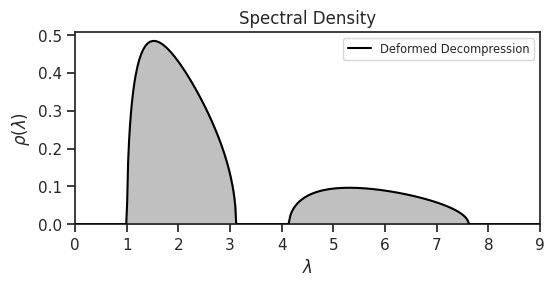

In [7]:
end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

x = numpy.linspace(x_min, x_max, 500)

# Settigns for _deform5.py
# newton_opt = dict(
#     dt_max=0.02,
#     sweep_pad=50,
# )

# Settings for _deform10_6d.py
newton_opt = dict(
    dt_max=0.01,
    dt_min=1e-9,
    tol=1e-10,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=False,
    pair_enable=False,
    pair_gap_factor=10.0,
)

rho, x = af.decompress(
    fd_sizes, x=x, kind='deformed', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0,
    verbose=True, plot=True, latex=False)

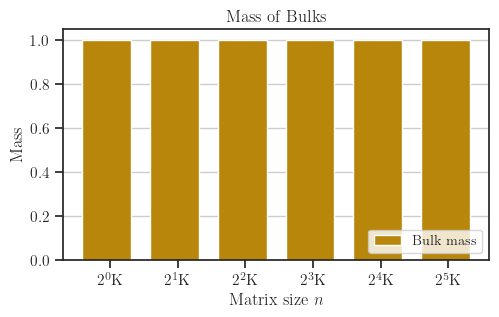

In [8]:
plot_mass(fd_sizes, x, rho, atoms=None, log_x=True, gap=0.7, save=False, latex=latex)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/dmp-flow.pdf".


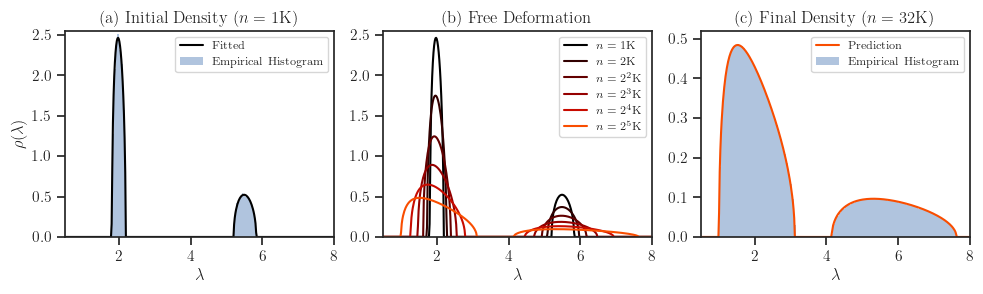

In [26]:
plot_flow(fd_sizes, x, rho, eigs[start_idx], eigs[end_idx], xlim=config['xlim'],
          ylim=config['ylim'], share_ax=False, layout='horizontal', title='Free Deformation',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=config['nbins'],
          label_mode=config['label_mode'],
          save=join(plot_dir, config['save_filename'] + '-flow.pdf'),
          latex=latex)

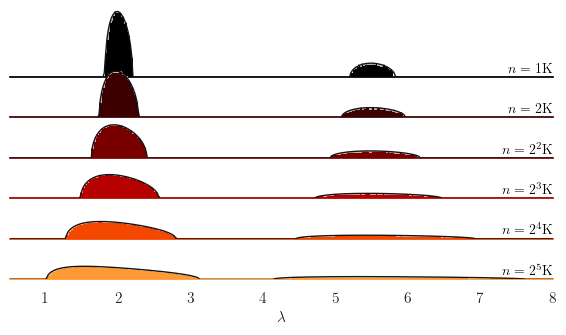

In [17]:
# Set zero density to be slihtly below axis to show background axis
rho_ = numpy.copy(rho)
rho_[rho_ < 1e-3] = -5e-3

ridgeplot(fd_sizes, x=x, rho=rho_, eigs=eigs, log=False,
          hspace=-0.4, figsize=(7, 3.5),
          ylim=None, scaley=False, ylim_factor=1.0,
          xlim=config['xlim'], rho_color='0.08',
          cmap=plt.cm.gist_heat, c_range=(0, 0.8),
          text_side='right',
          label_mode=config['label_mode'],
          nbins=200,
          save=False,
          # save=join(plot_dir, config['save_filename'] + '-ridge.pdf'))
          latex=latex)

# Edge

In [18]:
# fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)
# base = 1000
# fd_sizes = base * 2**(numpy.arange(numpy.log2(As.shape[0]/base),
#                                    numpy.log2(A.shape[0]/base)+0.01, 0.5))
# start_idx = 0
# end_idx = fd_sizes.size - 1

end_idx = sizes.size - 1
fd_sizes = sizes[start_idx:end_idx+1]

t_final = numpy.log(fd_sizes[-1] / fd_sizes[0])
t = numpy.linspace(0, t_final, 200)

# cusps, info = af.cusp(t, kind='deformed', supp=support, max_iter=200, tol=1e-8,
#                       dedup_t_tol=1e-6, dedup_x_tol=1e-6, return_info=True)

est_supp = af.support(return_info=False)

complex_edges, real_merged_edges, active_k, cusps = af.edge(
    t, kind='deformed',
    # supp=support,
    supp=est_supp,
    dt_max=0.01, max_iter=100, tol=1e-12)

print('Cusps:')
if len(cusps) > 0:
    for cusp in cusps:
        print(f'\tx: {cusp[0]:>0.3f}, t: {cusp[1]:>0.3f}')

Cusps:


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/dmp-edge.pdf".


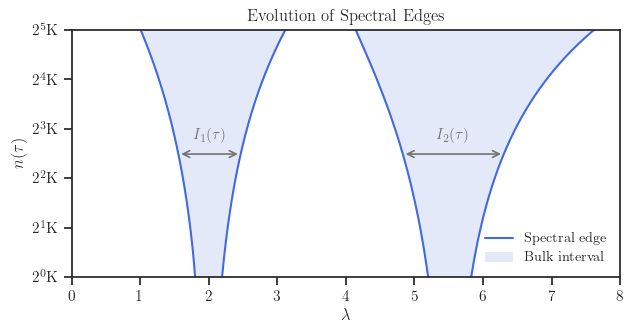

In [27]:
plot_edges(t, complex_edges, real_merged_edges, cusps=cusps, sizes=fd_sizes,
           # sizes=None,
           edge_color='royalblue', fill_color='royalblue', alpha=0.14,
           figsize=None, annotate=True, xlim=(0, 8), log_x=False, log_y=True,
           flip_y=False,
           save=join(plot_dir, config['save_filename'] + '-edge.pdf'), latex=latex)

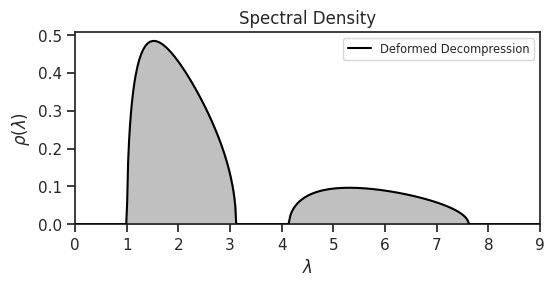

In [20]:
fd_sizes_plot = numpy.geomspace(sizes[start_idx], sizes[end_idx], t.size)

rho_plot, x = af.decompress(
    fd_sizes_plot, x=x, kind='deformed', method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=False,
    atom_eps=0, verbose=False, plot=True, latex=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/dmp-edge.pdf".


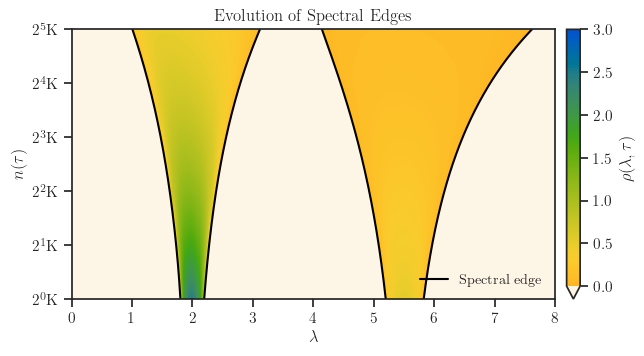

In [28]:
import colorcet as cc

# poisson = (af.delta / numpy.pi) / (xx**2 + af.delta**2)
r = numpy.copy(rho_plot)
# r = numpy.abs(r)
# r[r < poisson] = numpy.nan
# r[r < poisson] = poisson[r < poisson]

# r[(r < 1e-7) & numpy.logical_not(near_cusp)] = numpy.nan
# r[(numpy.abs(r) < 1e-7)] = numpy.nan
r[r < 1e-3] = numpy.nan

# Repair nan points very close to cusp
# near_cusp = (tt_ < 8e3) & (xx > 2e-3) & (xx < 5e-3)
# repair = near_cusp & numpy.isnan(r)
# r[repair] = 1e2 # poisson[repair]
# r[(xx < left_edges[:, None])] = numpy.nan


# t_emp = numpy.log(sizes[start_idx:end_idx+1] / sizes[start_idx])
# t_emp = sizes[start_idx:end_idx+1]
# e_emp = min_eigs[start_idx:end_idx+1]

# cmap = plt.cm.YlGnBu; c_range = (0, 0.99)
# cmap = plt.cm.RdPu; c_range = (0, 0.99)
# cmap = plt.cm.YlOrBr_r; c_range = (0, 0.9)
# cmap = plt.cm.afmhot_r; c_range = (0, 0.99)
# cmap = plt.cm.gist_heat_r; c_range = (0, 0.9)
# cmap = plt.cm.YlOrRd; c_range = (0, 1)
# cmap = cc.cm.CET_CBL3_r; c_range = (0.1, 1)# blue black
# cmap = cc.cm.CET_L20; c_range = (0.1, 1)  # no
# cmap = cc.cm.CET_L16; c_range = (0.2, 0.9) # Yell green blue
cmap = cc.cm.CET_R2_r; c_range = (0.3, 0.95)
# cmap = cc.cm.CET_R1_r; c_range = (0.4, 0.95)

cmap_trim = cmap.from_list('trimmed', cmap(numpy.linspace(c_range[0], c_range[1], 256)))

plot_edges(t, complex_edges, real_merged_edges,
           cusps=cusps,
           # cusps=None,
           sizes=fd_sizes,
           x=x, rho=r, cbar_range=(0, 3), cbar_log=False, cmap=cmap_trim,
           bg_color='oldlace', edge_color='black', fill_color='royalblue', alpha=0.14,
           figsize=(6.8, 3.725), annotate=False, annotate_color='0.3',
           xlim=(0, 8), log_x=False, log_y=True, flip_y=False,
           save=join(plot_dir, config['save_filename'] + '-edge.pdf'), latex=latex)